In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme()

In [ ]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape
df.head()
df.info()
df.describe(include='all')
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df = df.dropna().copy()

In [ ]:
df.isna().sum()
df.shape

(7032, 21)

In [ ]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.734215
Yes,0.265785




* Доля клиентов, покинувших компанию, составляет 26.6%, что указывает на наличие проблемы оттока
* Распределение целевой переменной является умеренно несбалансированным
*   Дисбаланс не критичен, однако должен учитываться при построении модели








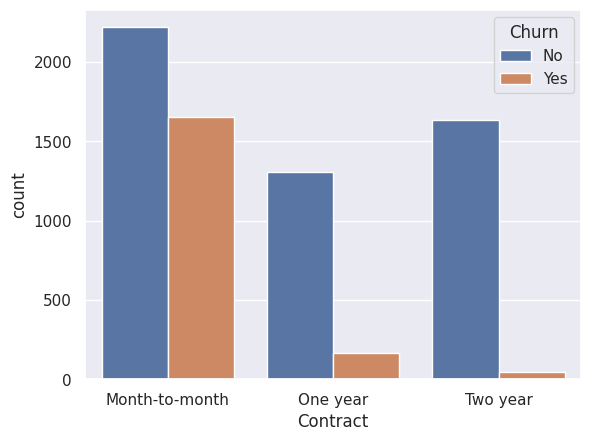

In [ ]:
sns.countplot(data=df, x='Contract', hue='Churn')
plt.show()





*   Клиенты с помесячным контрактом демонстрируют существенно более высокий уровень оттока
*   Долгосрочные контракты (1 и 2 года) связаны с более низкой вероятностью ухода
*   Двухлетний контракт практически полностью снижает риск churn



In [ ]:
df['Churn_flag'] = df['Churn'].map({'No': 0, 'Yes': 1})
(df.groupby('Contract')['Churn_flag'].mean() * 100).sort_values(ascending=False)

,Churn_flag
Contract,
Month-to-month,42.709677
One year,11.277174
Two year,2.848665








*   Тип контракта является одним из ключевых факторов, влияющих на отток клиентов

*   Клиенты с помесячным контрактом демонстрируют высокий уровень churn (42.7%)

*   Для клиентов с годовым контрактом уровень оттока снижается до 11.3%
*   Минимальный churn наблюдается у клиентов с двухлетним контрактом (2.8%)
*   Полученные результаты свидетельствуют о сильной обратной зависимости между длительностью контракта и вероятностью ухода




# **H1: Длительность контракта существенно влияет на вероятность оттока клиентов**

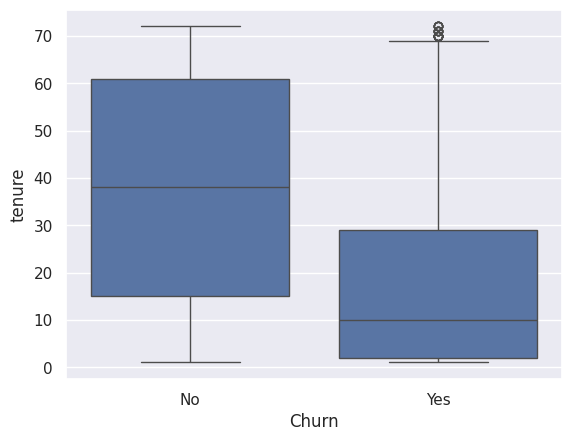

In [ ]:
sns.boxplot(data=df, x='Churn', y='tenure')
plt.show()

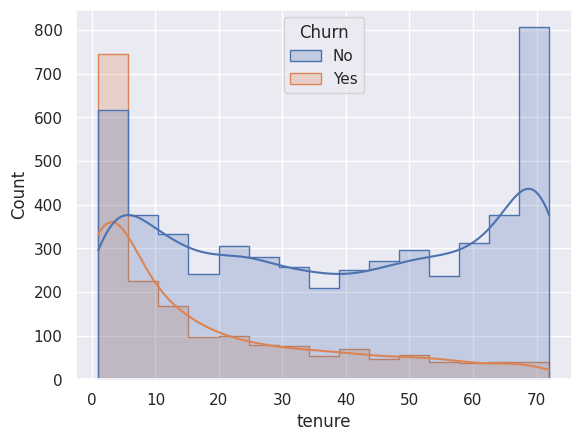

In [ ]:
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, element='step')
plt.show()



*   Срок взаимодействия клиента с компанией является значимым фактором, влияющим на отток клиентов  
*   Ушедшие клиенты характеризуются существенно меньшим значением tenure по сравнению с оставшимися  
*   Основной отток сосредоточен в первые месяцы обслуживания (до 10 месяцев)  
*   По мере увеличения срока взаимодействия вероятность ухода клиента снижается  
*   Клиенты с длительным стажем демонстрируют значительно более низкий уровень churn  

# **H2: Меньший срок взаимодействия клиента с компанией (tenure) связан с более высокой вероятностью оттока клиентов**

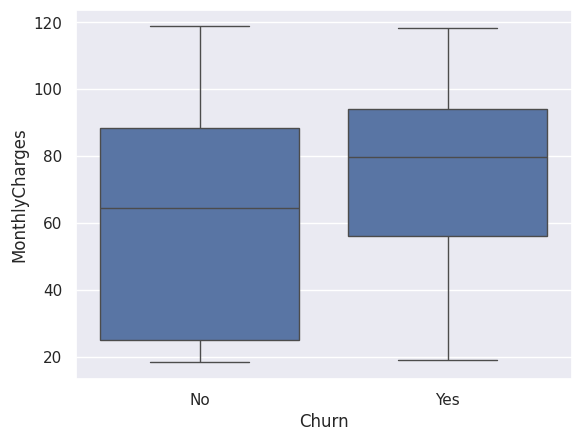

In [ ]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.show()

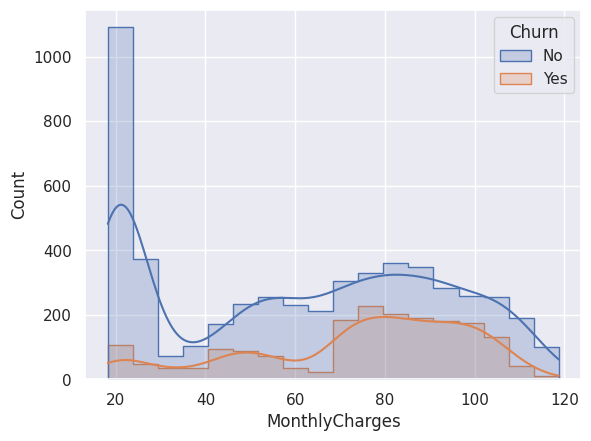

In [ ]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, element='step')
plt.show()


*   Ушедшие клиенты характеризуются более высоким уровнем ежемесячных платежей по сравнению с оставшимися  
*   Распределение MonthlyCharges для клиентов с churn смещено в сторону более высоких значений  
*   Клиенты с низкими еж

# **H3: Более высокий ежемесячный платёж (MonthlyCharges) связан с более высокой вероятностью оттока клиентов**


In [ ]:
(df.groupby('OnlineSecurity')['Churn_flag'].mean() * 100).sort_values(ascending=False)

,Churn_flag
OnlineSecurity,
No,41.778667
Yes,14.640199
No internet service,7.434211


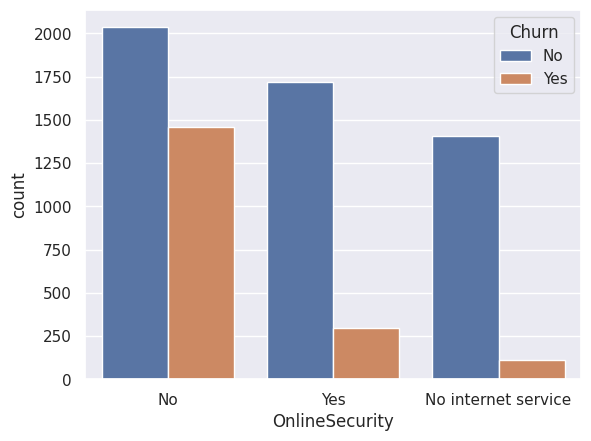

In [ ]:
sns.countplot(data=df, x='OnlineSecurity', hue='Churn')
plt.show()



*   Наличие услуги OnlineSecurity оказывает значительное влияние на уровень оттока клиентов  
*   Клиенты без подключения OnlineSecurity демонстрируют высокий уровень churn (41.8%)  
*   При наличии услуги OnlineSecurity уровень оттока существенно снижается (14.6%)  
*   Минимальный churn наблюдается у клиентов без интернет-сервиса (7.4%)  
*   Полученные результаты свидетельствуют о том, что дополнительные сервисы безопасности способствуют удержанию клиентов  

# **H4: Наличие услуги OnlineSecurity связано со снижением вероятности оттока клиентов**

In [ ]:
(df.groupby('TechSupport')['Churn_flag'].mean() * 100).sort_values(ascending=False)

,Churn_flag
TechSupport,
No,41.647465
Yes,15.196078
No internet service,7.434211


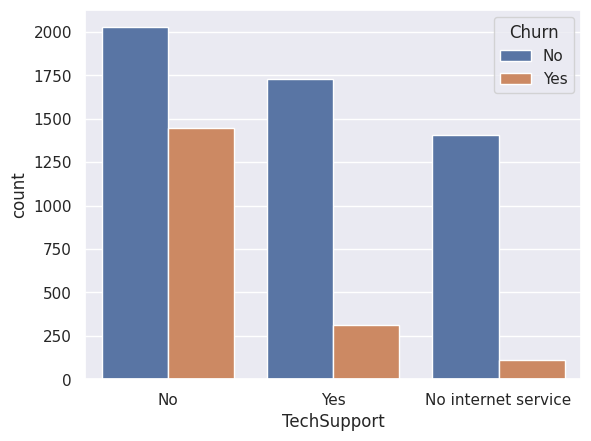

In [ ]:
sns.countplot(data=df, x='TechSupport', hue='Churn')
plt.show()



*   Наличие услуги технической поддержки оказывает значительное влияние на уровень оттока клиентов  
*   Клиенты без подключения TechSupport демонстрируют высокий уровень churn (41.6%)  
*   При наличии услуги TechSupport уровень оттока существенно снижается (15.2%)  
*   Минимальный churn наблюдается у клиентов без интернет-сервиса (7.4%)  
*   Полученные результаты свидетельствуют о том, что доступ к технической поддержке способствует удержанию клиентов  

# **H5: Наличие услуги технической поддержки (TechSupport) связано со снижением вероятности оттока клиентов**

# **Основные факторы оттока клиентов**

*   Ключевым фактором оттока является тип контракта: клиенты с помесячным контрактом значительно чаще покидают компанию  
*   Срок взаимодействия с клиентом (tenure) оказывает существенное влияние: наибольший отток наблюдается в первые месяцы  
*   Более высокий уровень ежемесячных платежей связан с повышенной вероятностью churn  
*   Отсутствие дополнительных сервисов, таких как OnlineSecurity и TechSupport, значительно увеличивает риск ухода клиента  
*   Клиенты с длительным стажем и подключенными дополнительными услугами демонстрируют наибольшую лояльность  

In [ ]:
from scipy.stats import chi2_contingency, ttest_ind

# **Проверка H1: Длительность контракта влияет на churn (chi-square)**

*   Построена таблица сопряженности между типом контракта и фактом оттока  
*   Проведен критерий хи-квадрат Пирсона  
*   Полученное значение p-value указывает на статистическую значимость различий (p < 0.05)  
*   Зависимость между типом контракта и оттоком клиентов подтверждена  

In [ ]:
table = pd.crosstab(df['Contract'], df['Churn'])
chi2, p, dof, exp = chi2_contingency(table)

print('p-value:', p)

p-value: 7.326182186265472e-257


# **Проверка H2: tenure влияет на churn (t-test)**

*   Сравнены средние значения tenure для ушедших и оставшихся клиентов  
*   Проведен t-тест для независимых выборок  
*   Полученное значение p-value свидетельствует о статистически значимых различиях (p < 0.05)  
*   Гипотеза о влиянии срока обслуживания на churn подтверждена  

In [ ]:
tenure_yes = df[df['Churn_flag'] == 1]['tenure']
tenure_no = df[df['Churn_flag'] == 0]['tenure']

stat, p = ttest_ind(tenure_yes, tenure_no)

print('p-value:', p)

p-value: 9.437650217574845e-207


# **Проверка H3: MonthlyCharges влияет на churn (t-test)**

*   Сравнены средние значения ежемесячных платежей для ушедших и оставшихся клиентов  
*   Проведен t-тест для независимых выборок  
*   Полученное значение p-value указывает на статистическую значимость различий (p < 0.05)  
*   Более высокий уровень платежей связан с увеличением вероятности оттока  

In [ ]:
mc_yes = df[df['Churn_flag'] == 1]['MonthlyCharges']
mc_no = df[df['Churn_flag'] == 0]['MonthlyCharges']

stat, p = ttest_ind(mc_yes, mc_no)

print('p-value:', p)

p-value: 6.760843117980302e-60


# **Проверка H4: OnlineSecurity влияет на churn (chi-square)**

*   Построена таблица сопряженности между наличием услуги OnlineSecurity и оттоком  
*   Проведен критерий хи-квадрат Пирсона  
*   Полученное значение p-value свидетельствует о статистической значимости различий (p < 0.05)  
*   Наличие услуги OnlineSecurity снижает вероятность оттока  

In [ ]:
table = pd.crosstab(df['OnlineSecurity'], df['Churn'])
chi2, p, dof, exp = chi2_contingency(table)

print('p-value:', p)

p-value: 1.4006867477839222e-184


# **Проверка H5: TechSupport влияет на churn (chi-square)**

*   Построена таблица сопряженности между наличием технической поддержки и оттоком  
*   Проведен критерий хи-квадрат Пирсона  
*   Полученное значение p-value подтверждает статистическую значимость различий (p < 0.05)  
*   Наличие технической поддержки снижает вероятность ухода клиентов  

In [ ]:
table = pd.crosstab(df['TechSupport'], df['Churn'])
chi2, p, dof, exp = chi2_contingency(table)

print('p-value:', p)

p-value: 7.407807748843711e-180


# **Результаты статистической проверки гипотез**

*   Для всех рассмотренных факторов получены значения p-value значительно ниже уровня значимости 0.05  
*   Это свидетельствует о наличии статистически значимых различий между группами клиентов  
*   Гипотезы о влиянии типа контракта, срока обслуживания, уровня платежей и наличия дополнительных услуг на вероятность оттока подтверждены  
*   Наиболее сильное влияние оказывают тип контракта и срок взаимодействия с клиентом  
*   Дополнительные услуги (OnlineSecurity, TechSupport) также играют важную роль в снижении churn  

In [ ]:
features = [
    'tenure',
    'MonthlyCharges',
    'Contract',
    'OnlineSecurity',
    'TechSupport'
]

In [ ]:
X = df[features]
y = df['Churn_flag']

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

confusion_matrix(y_test, y_pred)

Accuracy: 0.7825159914712153
Precision: 0.60828025477707
Recall: 0.5106951871657754
ROC-AUC: 0.8190864570768903


array([[910, 123],
       [183, 191]])

In [ ]:
coef = pd.Series(model.coef_[0], index=X.columns)
coef.sort_values(ascending=False)

,0
MonthlyCharges,0.799236
OnlineSecurity_No internet service,-0.135772
TechSupport_No internet service,-0.135772
TechSupport_Yes,-0.285557
OnlineSecurity_Yes,-0.305100
Contract_One year,-0.380645
Contract_Two year,-0.655504
tenure,-0.783679


# **Интерпретация модели**

*   Наиболее значимым фактором, увеличивающим вероятность оттока, является высокий уровень ежемесячных платежей  
*   Наиболее сильным фактором, снижающим churn, является длительный срок взаимодействия клиента с компанией  
*   Долгосрочные контракты (особенно двухлетние) существенно уменьшают вероятность ухода клиента  
*   Наличие дополнительных услуг, таких как OnlineSecurity и TechSupport, снижает риск оттока  
*   Полученные результаты согласуются с выводами разведочного анализа данных  

# **Бизнес-рекомендации**

*   Стимулировать клиентов переходить на долгосрочные контракты  
*   Усилить работу с новыми клиентами в первые месяцы взаимодействия  
*   Пересмотреть ценовую политику для клиентов с высоким уровнем MonthlyCharges  
*   Продвигать дополнительные услуги (OnlineSecurity, TechSupport) как инструмент удержания  
*   Разработать программы удержания для клиентов с высоким риском churn  

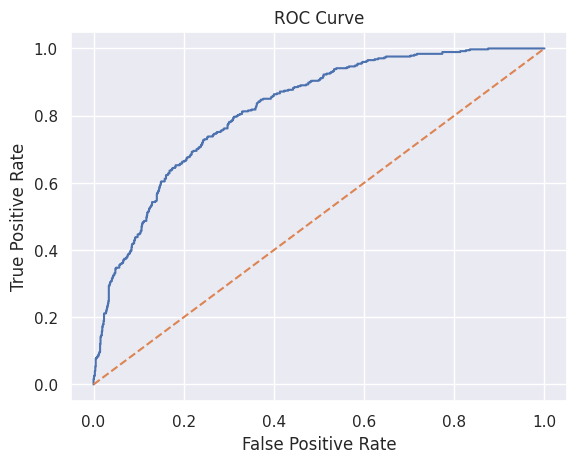

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

# **Оценка качества модели**

*   ROC-кривая демонстрирует высокую способность модели разделять классы  
*   Значение ROC-AUC = 0.82 свидетельствует о хорошем качестве модели  
*   Кривая существенно отклоняется от линии случайного угадывания  
*   Модель эффективно выявляет клиентов с высоким риском оттока  

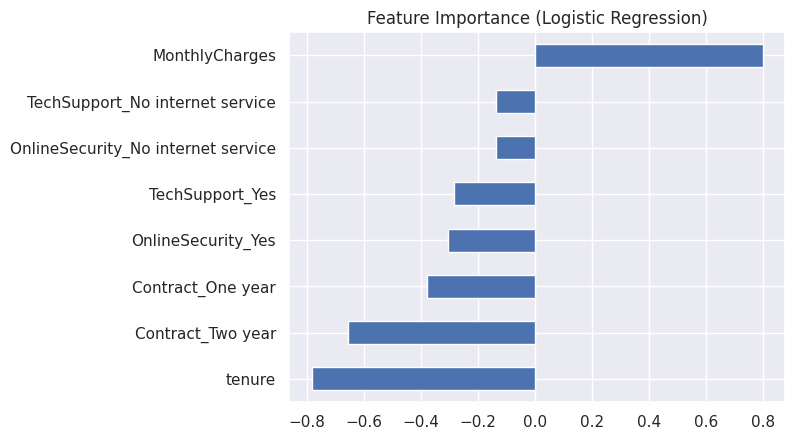

In [ ]:
coef = pd.Series(model.coef_[0], index=X.columns).sort_values()

coef.plot(kind='barh')
plt.title('Feature Importance (Logistic Regression)')
plt.show()

# **Анализ влияния факторов (модель)**

*   Наиболее сильным фактором, увеличивающим вероятность оттока, является высокий уровень ежемесячных платежей (MonthlyCharges)  
*   Наиболее значимым фактором, снижающим churn, является срок взаимодействия с клиентом (tenure)  
*   Двухлетний контракт оказывает максимальный удерживающий эффект среди всех типов контрактов  
*   Наличие дополнительных услуг (OnlineSecurity, TechSupport) снижает вероятность ухода клиента  
*   Полученные результаты полностью согласуются с выводами разведочного анализа  

In [ ]:
df_test = X_test.copy()
df_test['churn_prob'] = y_prob

df_test['risk_segment'] = pd.cut(
    df_test['churn_prob'],
    bins=[0, 0.3, 0.6, 1],
    labels=['Low', 'Medium', 'High']
)

df_test['risk_segment'].value_counts(normalize=True)

,proportion
risk_segment,
Low,0.611940
Medium,0.249467
High,0.138593


# **Сегментация клиентов по риску оттока**

*   Большая часть клиентов относится к сегменту с низким риском оттока (61.2%)  
*   Около четверти клиентов находятся в зоне среднего риска (24.9%)  
*   Сегмент высокого риска составляет 13.9% клиентов и требует приоритетного внимания  
*   Сегментация позволяет эффективно распределять ресурсы на удержание клиентов  

# **Итоговые выводы исследования**

*   Ключевыми факторами оттока являются тип контракта, срок взаимодействия с клиентом и уровень ежемесячных платежей  
*   Основной отток происходит на ранних этапах жизненного цикла клиента  
*   Дополнительные услуги играют важную роль в повышении лояльности клиентов  
*   Модель логистической регрессии подтверждает выявленные зависимости и позволяет прогнозировать churn  
*   Полученные результаты имеют практическую ценность для бизнеса и могут быть использованы для снижения оттока клиентов  

# **Практическое применение результатов**

*   Модель может использоваться для автоматического выявления клиентов с высоким риском оттока  
*   Позволяет формировать таргетированные кампании по удержанию клиентов  
*   Обеспечивает повышение эффективности маркетинговых и продуктовых решений  
*   Может быть интегрирована в CRM-систему для поддержки принятия решений  